3.3. Autoregressive Models


In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from pymongo import MongoClient
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

warnings.simplefilter(action="ignore", category=FutureWarning)


🛠️ Instruction: Locate the IP address of the machine running MongoDB and assign it to the variable host. Make sure to use a string (i.e., wrap the IP in quotes).

⚠️ Note: The IP address is dynamic — it may change every time you start the lab. Always check the current IP before proceeding.


In [3]:
host = "192.204.59.3"

# Prepare Data


## Import


Next, complete the code to create a client to connect to the MongoDB server running at `host` on port `27017`, assigns the `"air-quality"` database to `db`, and assigned the `"nairobi"` connection to `nairobi`.


In [5]:
client = MongoClient(host="192.255.221.2", port = 27017)
db = client["air-quality"]
nairobi = db["nairobi"]

Next, we Change the `wrangle` function below so that it returns a Series of the resampled data instead of a DataFrame.


In [7]:
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    # Read data into DataFrame
    df = pd.DataFrame(list(results)).set_index("timestamp")

    # Localize timezone
    df.index = df.index.tz_localize("UTC").tz_convert("Africa/Nairobi")

    # Remove outliers
    df = df[df["P2"] < 500]

    # Resample to 1hr window
    y = df["P2"].resample("1H").mean().fillna(method='ffill')

    return y

Next, we Use your wrangle function to read the data from the `nairobi` collection into the Series `y`.


In [8]:
y = wrangle(nairobi)
y.head()

timestamp
2018-09-01 03:00:00+03:00    17.541667
2018-09-01 04:00:00+03:00    15.800000
2018-09-01 05:00:00+03:00    11.420000
2018-09-01 06:00:00+03:00    11.614167
2018-09-01 07:00:00+03:00    17.665000
Freq: H, Name: P2, dtype: float64

In [9]:
# Check your work
assert isinstance(y, pd.Series), f"`y` should be a Series, not type {type(y)}"
assert len(y) == 2928, f"`y` should have 2928 observations, not {len(y)}"
assert y.isnull().sum() == 0

## Explore


Next, we Create an ACF plot for the data in `y`. Be sure to label the x-axis as `"Lag [hours]"` and the y-axis as `"Correlation Coefficient"`.


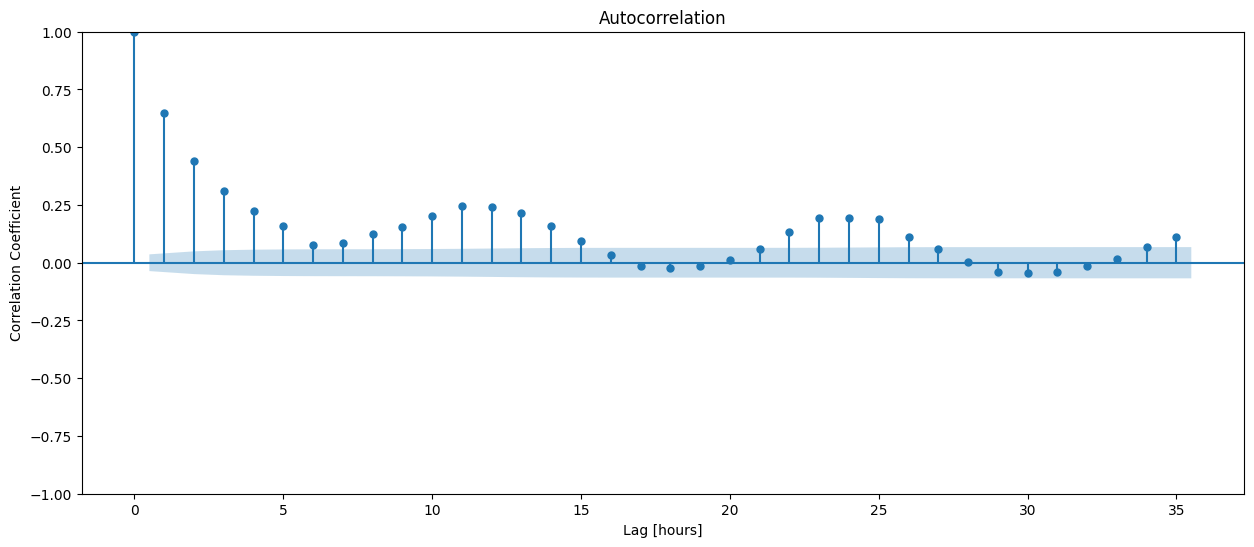

In [11]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

Next, we Create an PACF plot for the data in `y`. Be sure to label the x-axis as `"Lag [hours]"` and the y-axis as `"Correlation Coefficient"`.


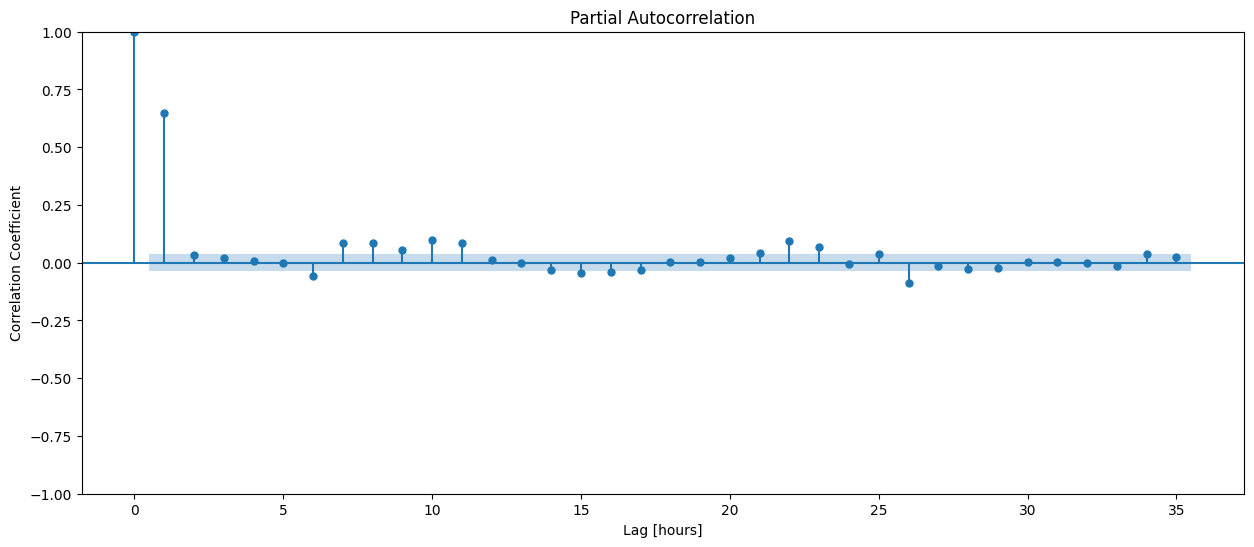

In [13]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(y, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

## Split


Next, we Split `y` into training and test sets. The first 95% of the data should be in your training set. The remaining 5% should be in the test set.


In [15]:
cutoff_test = int(len(y) * 0.95)

y_train =y.iloc[:cutoff_test]
y_test =y.iloc[cutoff_test:]

In [16]:
len(y_train) + len(y_test) == len(y)

True

# Build Model


## Baseline


Next, we Calculate the baseline mean absolute error for your model.


In [17]:
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean P2 Reading:", round(y_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 9.22
Baseline MAE: 3.71


## Iterate


Next, we Instantiate an [`AutoReg`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AutoReg.html) model and fit it to the training data `y_train`. Be sure to set the `lags` argument to `26`.


In [22]:
model = AutoReg(y_train, lags=26).fit()

Next, we Generate a list of training predictions for your model and use them to calculate your training mean absolute error.


In [23]:
y_pred = model.predict().dropna()
training_mae = mean_absolute_error(y_train.iloc[26:], y_pred)
print("Training MAE:", training_mae)

Training MAE: 2.2809871656467


Next, we Use `y_train` and `y_pred` to calculate the residuals for your model.


In [26]:
y_train_resid = model.resid
y_train_resid.tail()

timestamp
2018-12-25 19:00:00+03:00   -0.392002
2018-12-25 20:00:00+03:00   -1.573180
2018-12-25 21:00:00+03:00   -0.735747
2018-12-25 22:00:00+03:00   -2.022221
2018-12-25 23:00:00+03:00   -0.061916
Freq: H, dtype: float64

Next, we Create a plot of `y_train_resid`.


<Axes: xlabel='timestamp', ylabel='Residual Value'>

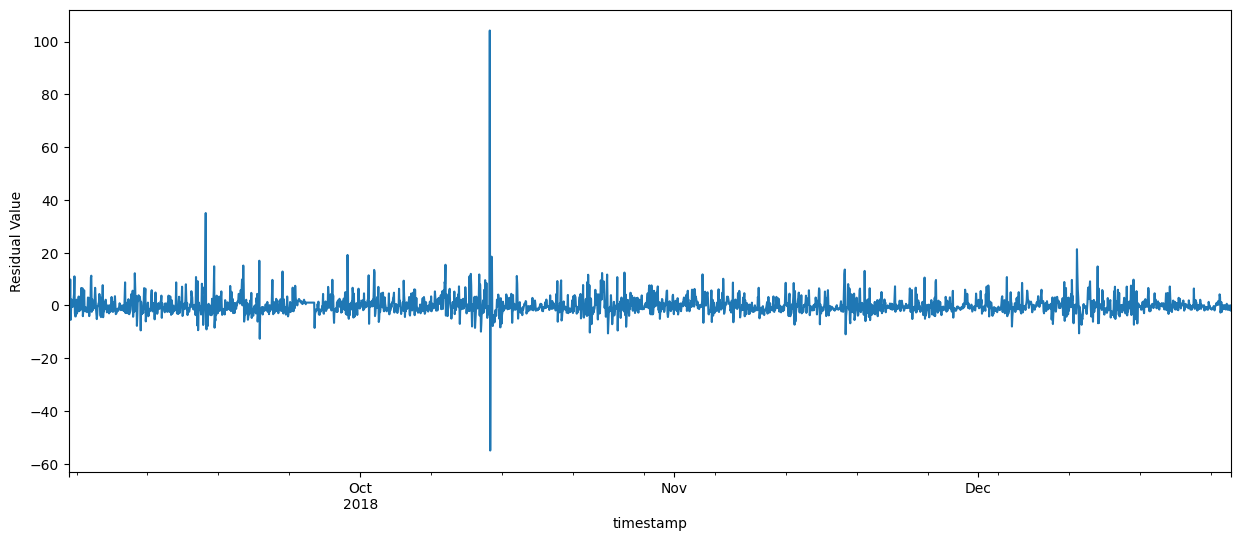

In [30]:
fig, ax = plt.subplots(figsize=(15, 6))
y_train_resid.plot(ylabel="Residual Value",ax=ax)

Next, we Create a histogram of `y_train_resid`.


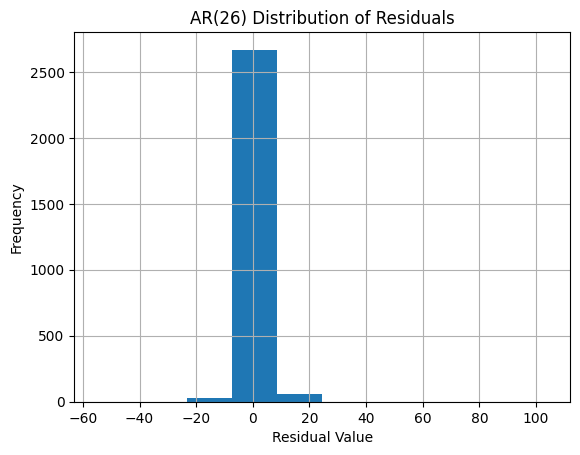

In [34]:
y_train_resid.hist()
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("AR(26) Distribution of Residuals");

Next, we Create an ACF plot of `y_train_resid`.


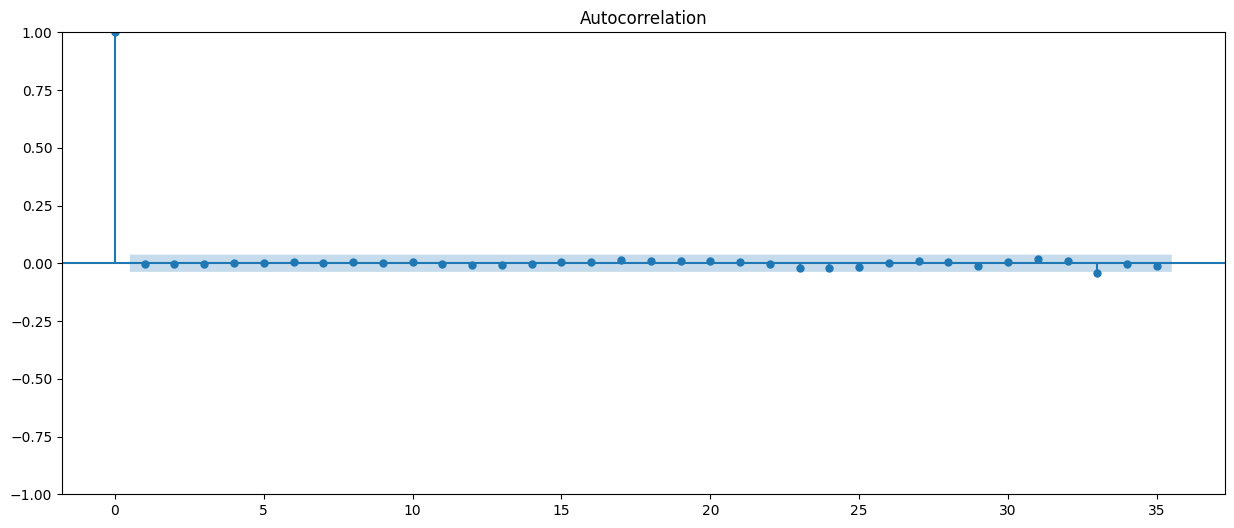

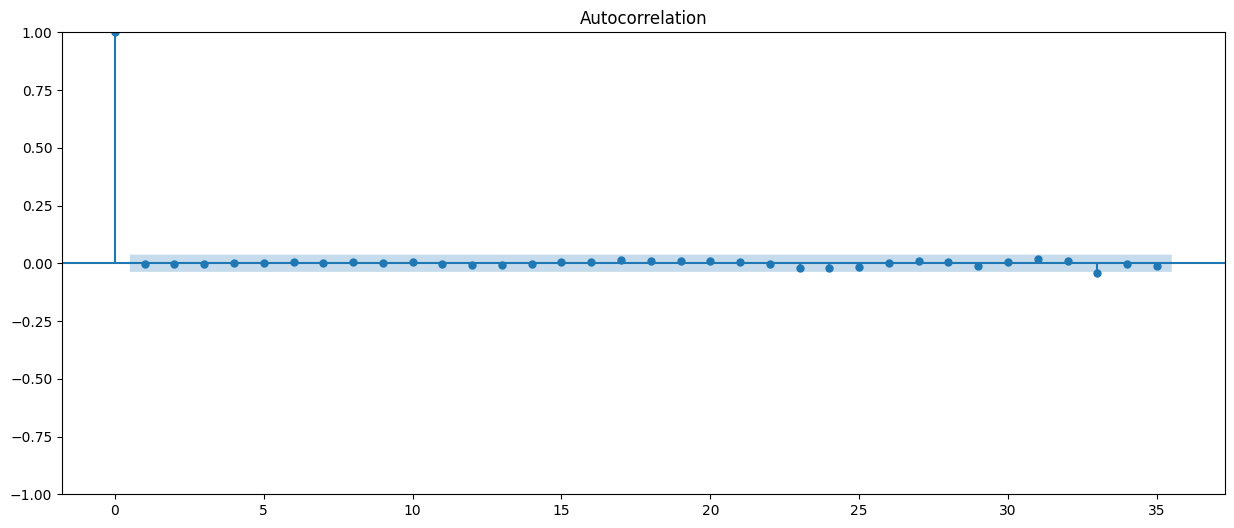

In [35]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y_train_resid, ax=ax)

## Evaluate


Next, we Calculate the test mean absolute error for your model.


Timestamp('2018-12-26 00:00:00+0300', tz='Africa/Nairobi', freq='H')

In [39]:
y_pred_test = model.predict(y_test.index.min(), y_test.index.max())
test_mae = mean_absolute_error(y_test, y_pred_test)
print("Test MAE:", test_mae)

Test MAE: 3.013643949503859


Next, we Create a DataFrame `test_predictions` that has two columns: `"y_test"` and `"y_pred"`. The first should contain the true values for your test set, and the second should contain your model's predictions. Be sure the index of `test_predictions` matches the index of `y_test`.


In [44]:
df_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred": y_pred_test}, index=y_test.index
)

Next, we Create a time series plot for the values in `test_predictions` using plotly express. Be sure that the y-axis is properly labeled as `"P2"`.


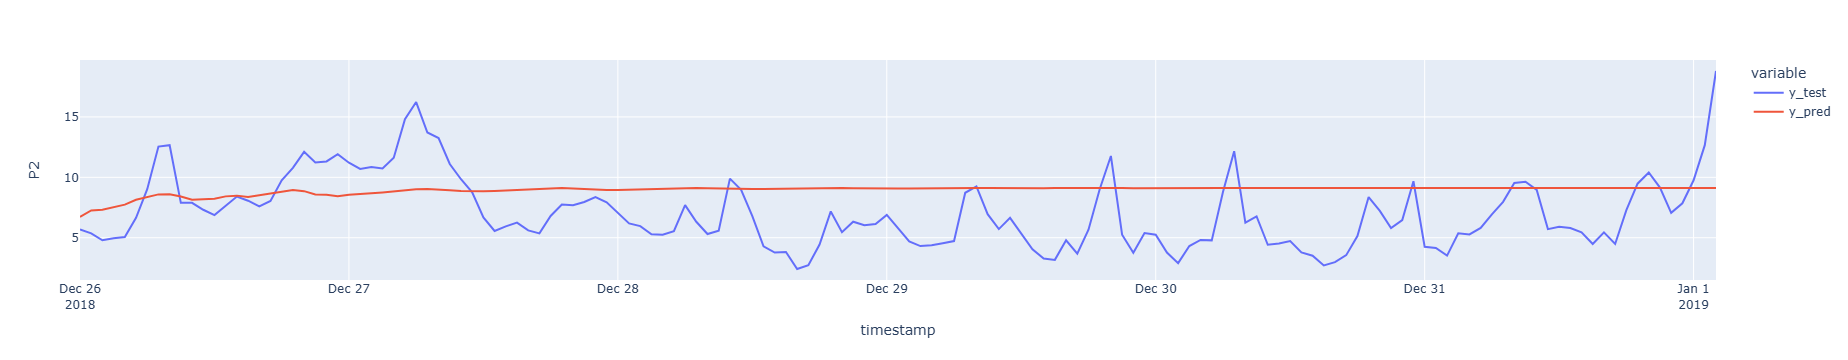

In [43]:
fig = px.line(df_pred_test, labels={"value": "P2"})
fig.show()

Next, we Perform walk-forward validation for your model for the entire test set `y_test`. Store your model's predictions in the Series `y_pred_wfv`.


In [54]:
%%capture

y_pred_wfv = pd.Series()
history = y_train.copy()
for i in range(len(y_test)):
    model= AutoReg(history, lags =26).fit()
    next_pred = model.forecast()
    y_pred_wfv = y_pred_wfv.append(next_pred)
    history = history.append(y_test[next_pred.index])

Next, we Calculate the test mean absolute error for your model.


In [56]:
test_mae = mean_absolute_error(y_test,y_pred_wfv)
print("Test MAE (walk forward validation):", round(test_mae, 2))

Test MAE (walk forward validation): 1.4


# Communicate Results


Next, we Print out the parameters for your trained model.


In [58]:
print(model.params)

const     2.011432
P2.L1     0.587118
P2.L2     0.019796
P2.L3     0.023615
P2.L4     0.027187
P2.L5     0.044014
P2.L6    -0.102128
P2.L7     0.029583
P2.L8     0.049867
P2.L9    -0.016897
P2.L10    0.032438
P2.L11    0.064360
P2.L12    0.005987
P2.L13    0.018375
P2.L14   -0.007636
P2.L15   -0.016075
P2.L16   -0.015953
P2.L17   -0.035444
P2.L18    0.000756
P2.L19   -0.003907
P2.L20   -0.020655
P2.L21   -0.012578
P2.L22    0.052499
P2.L23    0.074229
P2.L24   -0.023806
P2.L25    0.090577
P2.L26   -0.088323
dtype: float64


Next, we Put the values for `y_test` and `y_pred_wfv` into the DataFrame `df_pred_test` (don't forget the index). Then plot `df_pred_test` using plotly express.


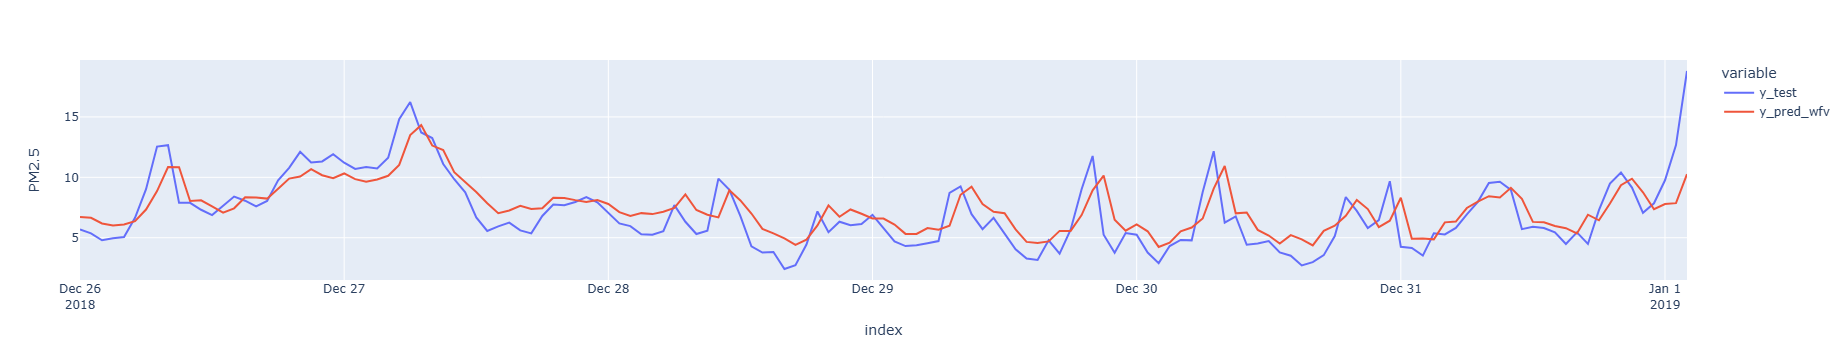

In [60]:
df_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred_wfv": y_pred_wfv}
)

fig = px.line(df_pred_test, labels={"value": "PM2.5"})
fig.show()

---

content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
